# 7 — Interpretation of LCA Results

A single LCA score tells you little on its own. Interpretation means understanding *where* the score comes from, *which processes drive it*, and *whether the conclusion holds across different impact methods*. This notebook demonstrates the main tools for answering those questions using the Swiss garden system from notebook 2.

**Topics covered:**
- Process contribution analysis — which activities drive the score?
- Elementary flow contribution — which emissions and resource uses matter most?
- Life-cycle phase breakdown across multiple impact methods
- Multi-method comparison using a heatmap
- Recursive supply-chain traversal with `bw2analyzer`
- Statistical concentration of impacts (Gini coefficient, Herfindahl index)
- Structured graph traversal with `bw_graph_tools` — building `Node`/`Edge`/`Flow` DataFrames and tracing supply-chain paths

**Prerequisite:** Run notebook 2 first to create the `"BAFU 2025 v2"` project and the `"Swiss garden foreground"` database.

In [1]:
import bw2data as bd
import bw2calc as bc
import bw2analyzer as ba
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from bw2analyzer.econ import gini_coefficient, herfindahl_index, concentration_ratio, theil_index
from bw_graph_tools import NewNodeEachVisitGraphTraversal, GraphTraversalSettings

pd.set_option('display.float_format', '{:.4g}'.format)
pd.set_option('display.max_colwidth', 55)

In [2]:
bd.projects.set_current("BAFU 2025 v2")

# Foreground product nodes (created in notebook 2)
garden_prod = bd.get_node(database="Swiss garden foreground", code="garden_system_prod")
constr_prod = bd.get_node(database="Swiss garden foreground", code="construction_prod")
maint_prod  = bd.get_node(database="Swiss garden foreground", code="annual_maintenance_prod")
waste_prod  = bd.get_node(database="Swiss garden foreground", code="green_waste_prod")
eol_prod    = bd.get_node(database="Swiss garden foreground", code="end_of_life_prod")

# Foreground process nodes — needed for supply-chain traversal
constr_proc = bd.get_node(database="Swiss garden foreground", code="construction_proc")
maint_proc  = bd.get_node(database="Swiss garden foreground", code="annual_maintenance_proc")

# Background node used for recursive traversal demo
excavation = bd.get_node(
    database="BAFU-2025-v2",
    name="Excavation, hydraulic digger, average",
    location="CH",
)

METHODS = [
    ("Ecological Scarcity 2021", "Global warming"),
    ("Ecological Scarcity 2021", "Main air pollutants and PM"),
    ("Ecological Scarcity 2021", "Water pollutants"),
    ("Ecological Scarcity 2021", "Land use"),
]

PHASE_COLORS = {
    "Construction":           "#1b4332",
    "Maintenance (×20)":     "#40916c",
    "Waste treatment (×20)": "#95d5b2",
    "End of life":            "#d8f3dc",
}

print(f"Project: {bd.projects.current}")
print(f"Foreground nodes: {len(bd.Database('Swiss garden foreground'))}")
print(f"Background nodes: {len(bd.Database('BAFU-2025-v2'))}")
print(f"LCIA methods available: {len(list(bd.methods))}")

Project: BAFU 2025 v2
Foreground nodes: 10
Background nodes: 11747
LCIA methods available: 21


---

## 1 — Contribution Analysis by Process

After solving the LCA equations, `lca.characterized_inventory` is a sparse matrix with shape *(elementary flows × processes)*. Entry $(i, j)$ is the LCIA impact attributed to elementary flow $i$ from process $j$.

Summing across rows gives the **per-process impact** — how much each process in the supply chain contributes to the total score. `bw2analyzer` automates this and maps column indices back to database metadata:

```python
ba.ContributionAnalysis().annotated_top_processes(lca, limit=15)
# → list of (score, supply_amount, activity_node)
```

The `supply_amount` is how much of that process runs (from `lca.supply_array`). The `score` is the fraction of the total LCIA score attributable to that process.

In [3]:
# Run the full garden LCA for global warming
lca = bc.LCA({garden_prod: 1}, method=METHODS[0])
lca.lci()
lca.lcia()

print(f"Functional unit: 1 Swiss garden, 100 m², 20 years")
print(f"Method:          {METHODS[0][1]}")
print(f"Total score:     {lca.score:,.0f} UBP")
print(f"\nTechnosphere matrix: {lca.technosphere_matrix.shape}")
print(f"Characterized inventory: {lca.characterized_inventory.shape}")

Functional unit: 1 Swiss garden, 100 m², 20 years
Method:          Global warming
Total score:     377,568 UBP

Technosphere matrix: (11752, 11752)
Characterized inventory: (2678, 11752)


/Users/cmutel/virtualenvs/trondheim/lib/python3.14/site-packages/scikits/umfpack/umfpack.py:737: UmfpackWarning: (almost) singular matrix! (estimated cond. number: 1.56e+12)
  warnings.warn(msg, UmfpackWarning)


In [4]:
# Top 15 contributing processes — raw output
ca = ba.ContributionAnalysis()
top_procs = ca.annotated_top_processes(lca, limit=15)

# Build a DataFrame for display and plotting
rows = []
for score, supply, act in top_procs:
    rows.append({
        'Process': act['name'],
        'Location': act.get('location', 'GLO'),
        'Database': act['database'],
        'Score (UBP)': score,
        '% of total': 100 * abs(score) / abs(lca.score),
        'Supply': supply,
    })
df_procs = pd.DataFrame(rows)
df_procs[['Process', 'Location', 'Score (UBP)', '% of total']]

,Process,Location,Score (UBP),% of total
0,"Diesel, burned in building machine, average",CH,9.593e+04,25.41
1,"Transport, freight, lorry, diesel, 18t gross weight...",CH,6.417e+04,16.99
2,"Natural gas, vented",GLO,6.166e+04,16.33
3,"Clinker, at plant",CH,1.138e+04,3.013
4,"Pig iron, at plant",RER,1.093e+04,2.894
5,"Transport, freight, lorry, diesel, 40t gross weight...",RER,9892,2.62
6,"Excavation, hydraulic digger, average",CH,7875,2.086
7,"Transport, freight, lorry, diesel, 32t gross weight...",CH,6998,1.853
8,"Transport, freight, lorry, diesel, 40t gross weight...",RER,6895,1.826
9,"Blast furnace gas, burned in power plant",RER,6818,1.806


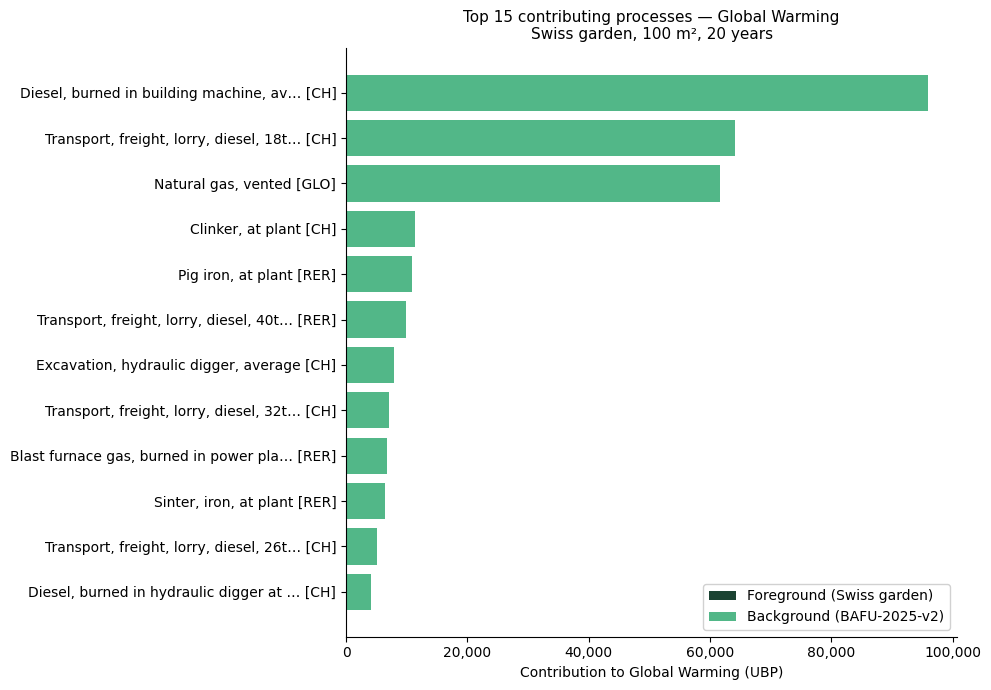

In [5]:
# Horizontal bar chart — top 15 processes by contribution
fig, ax = plt.subplots(figsize=(10, 7))

labels = [
    f"{row['Process'][:38]}… [{row['Location']}]" if len(row['Process']) > 38
    else f"{row['Process']} [{row['Location']}]"
    for _, row in df_procs.iterrows()
]
colors = [
    '#1b4332' if db == 'Swiss garden foreground' else '#52b788'
    for db in df_procs['Database']
]

ax.barh(labels, df_procs['Score (UBP)'], color=colors)
ax.set_xlabel("Contribution to Global Warming (UBP)", fontsize=10)
ax.set_title(
    "Top 15 contributing processes — Global Warming\n"
    "Swiss garden, 100 m², 20 years",
    fontsize=11,
)
ax.invert_yaxis()
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

legend_elements = [
    Patch(facecolor='#1b4332', label='Foreground (Swiss garden)'),
    Patch(facecolor='#52b788', label='Background (BAFU-2025-v2)'),
]
ax.legend(handles=legend_elements, loc='lower right', framealpha=0.9)
plt.tight_layout()
plt.show()

---

## 2 — Contribution Analysis by Elementary Flow

Summing `lca.characterized_inventory` along the *column* axis (axis=1) gives the **per-elementary-flow contribution** — which biosphere flows (emissions, resource uses) accumulate the most impact across the entire supply chain.

This answers a different question from the process contribution: instead of *which activity is responsible*, you see *which substance is most significant*.

In [6]:
top_flows = ca.annotated_top_emissions(lca, limit=12)

rows = []
for score, supply, flow in top_flows:
    rows.append({
        'Elementary flow': flow['name'],
        'Categories': ' > '.join(flow.get('categories', [])),
        'Score (UBP)': score,
        '% of total': 100 * abs(score) / abs(lca.score),
    })
df_flows = pd.DataFrame(rows)
df_flows[['Elementary flow', 'Categories', 'Score (UBP)', '% of total']]

,Elementary flow,Categories,Score (UBP),% of total
0,"Carbon dioxide, fossil",emissions to air,3.042e+05,80.57
1,"Methane, fossil",emissions to air,6.243e+04,16.53
2,Carbon dioxide,emissions to air,4419,1.17
3,Dinitrogen monoxide,emissions to air,2861,0.7578
4,Sulfur hexafluoride,emissions to air,1715,0.4541
5,"Carbon monoxide, fossil",emissions to air,1485,0.3933
6,"Ethane, 1,1,1,2-tetrafluoro-, HFC-134a",emissions to air,312.8,0.08284
7,"Methane, tetrafluoro-, CFC-14",emissions to air,121.2,0.03211
8,"Ethane, hexafluoro-, HFC-116",emissions to air,20.21,0.005352
9,"Methane, biogenic",emissions to air,1.844,0.0004884


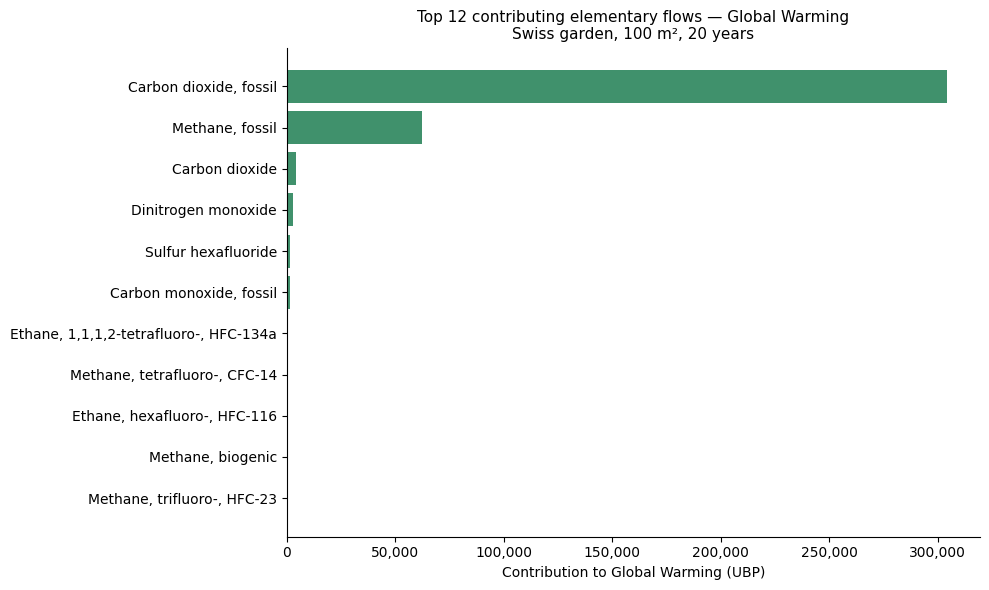

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

flow_labels = [
    f"{row['Elementary flow'][:42]}…" if len(row['Elementary flow']) > 42
    else row['Elementary flow']
    for _, row in df_flows.iterrows()
]

ax.barh(flow_labels, df_flows['Score (UBP)'], color='#40916c')
ax.set_xlabel("Contribution to Global Warming (UBP)", fontsize=10)
ax.set_title(
    "Top 12 contributing elementary flows — Global Warming\n"
    "Swiss garden, 100 m², 20 years",
    fontsize=11,
)
ax.invert_yaxis()
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

---

## 3 — Life-Cycle Phase Breakdown

The overall score aggregates four distinct life-cycle phases. By re-running the LCA with each phase as a separate functional unit, we can see which stage dominates and whether the ranking changes across impact methods.

The trick is to reuse the already-factorised technosphere matrix: `lca.redo_lci(new_demand)` substitutes a new demand vector without recomputing the LU decomposition of **A**, making multi-product runs 10–100× faster than creating a new `LCA` object each time.

In [8]:
phase_demands = {
    "Construction":           {constr_prod.id: 1},
    "Maintenance (×20)":     {maint_prod.id: 20},
    "Waste treatment (×20)": {waste_prod.id: 20},
    "End of life":            {eol_prod.id: 1},
}

results = {}
for method in METHODS:
    label = method[1]
    results[label] = {}
    lca.switch_method(method)
    for phase, fu in phase_demands.items():
        lca.redo_lci(fu)
        lca.redo_lcia()
        results[label][phase] = lca.score

results_df = pd.DataFrame(results)
print("Phase scores by impact category (UBP):")
results_df

/Users/cmutel/virtualenvs/trondheim/lib/python3.14/site-packages/scikits/umfpack/umfpack.py:737: UmfpackWarning: (almost) singular matrix! (estimated cond. number: 1.56e+12)
  warnings.warn(msg, UmfpackWarning)


Phase scores by impact category (UBP):


,Global warming,Main air pollutants and PM,Water pollutants,Land use
Construction,3.146e+05,5.88e+04,5791,5732
Maintenance (×20),4.695e+04,6024,1559,1075
Waste treatment (×20),5812,678.7,147.4,45.6
End of life,1.023e+04,1481,126.7,198.5


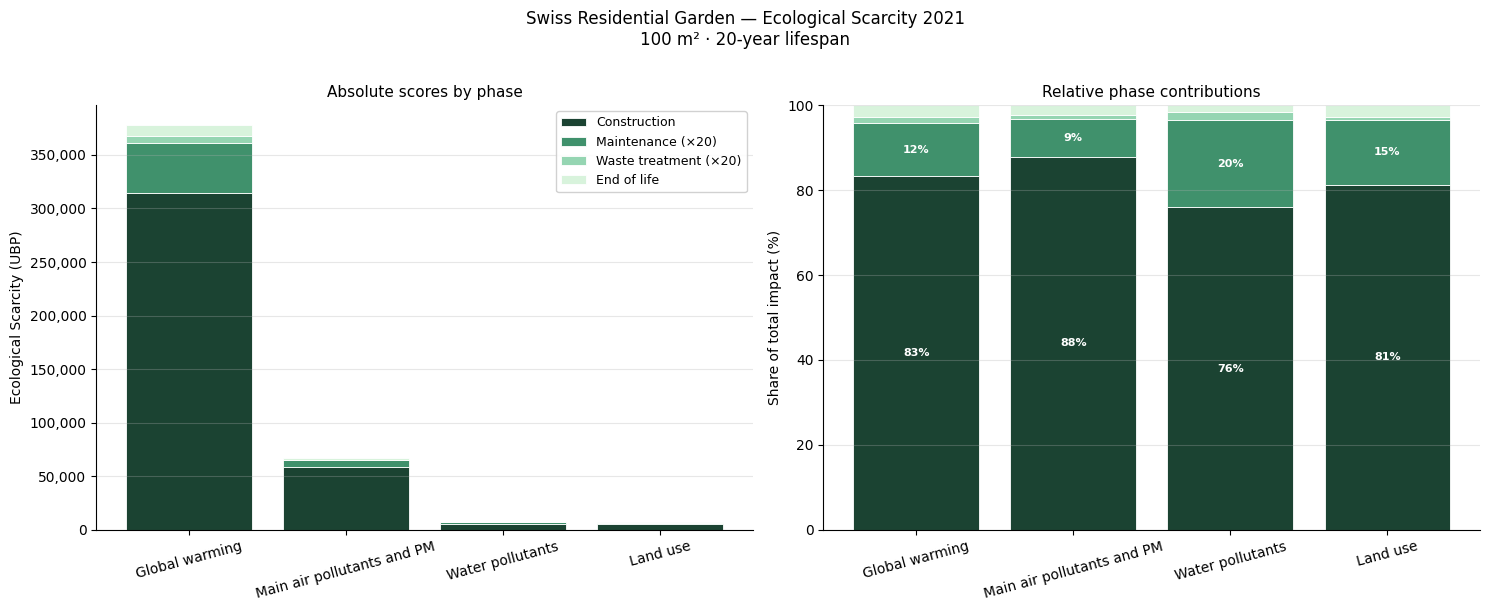

In [9]:
results_pct = results_df.div(results_df.sum(axis=0), axis=1) * 100

phases = list(phase_demands.keys())
method_labels = [m[1] for m in METHODS]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Left: absolute scores ─────────────────────────────────────────────────────
ax = axes[0]
bottom = np.zeros(len(method_labels))
for phase in phases:
    vals = results_df.loc[phase].values
    ax.bar(method_labels, vals, bottom=bottom,
           label=phase, color=PHASE_COLORS[phase],
           edgecolor='white', linewidth=0.6)
    bottom += vals

ax.set_ylabel("Ecological Scarcity (UBP)", fontsize=10)
ax.set_title("Absolute scores by phase", fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.tick_params(axis='x', labelrotation=15)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
ax.legend(loc='upper right', framealpha=0.9, fontsize=9)

# ── Right: normalised (%) ─────────────────────────────────────────────────────
ax = axes[1]
bottom = np.zeros(len(method_labels))
for phase in phases:
    vals = results_pct.loc[phase].values
    ax.bar(method_labels, vals, bottom=bottom,
           label=phase, color=PHASE_COLORS[phase],
           edgecolor='white', linewidth=0.6)
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 7:
            ax.text(i, b + v / 2, f"{v:.0f}%",
                    ha='center', va='center', fontsize=8,
                    color='white', fontweight='bold')
    bottom += vals

ax.set_ylabel("Share of total impact (%)", fontsize=10)
ax.set_title("Relative phase contributions", fontsize=11)
ax.set_ylim(0, 100)
ax.tick_params(axis='x', labelrotation=15)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)

fig.suptitle(
    "Swiss Residential Garden — Ecological Scarcity 2021\n"
    "100 m² · 20-year lifespan",
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.show()

---

## 4 — Multi-Method Comparison: Heatmap

The stacked bar charts above show four methods side by side, but it's still hard to spot where the *rankings shift* between categories. A heatmap makes phase-by-method patterns immediately visible: each row is normalised to 100% so you can compare the relative dominance of each phase across methods.

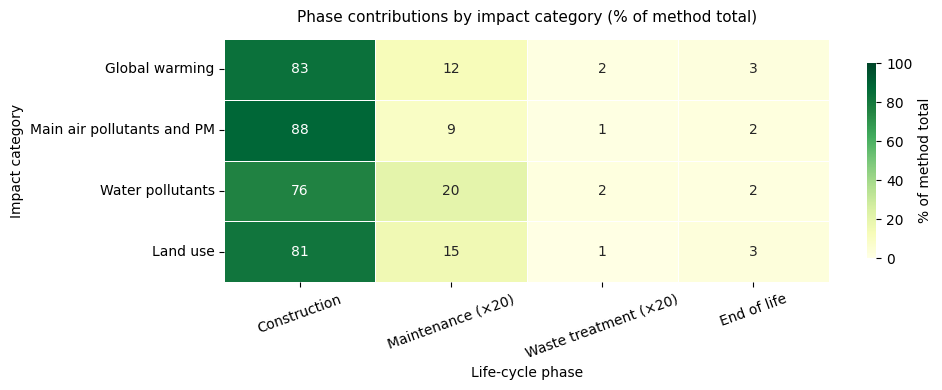

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))

sns.heatmap(
    results_pct.T,
    annot=True,
    fmt='.0f',
    cmap='YlGn',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': '% of method total', 'shrink': 0.8},
    vmin=0,
    vmax=100,
    annot_kws={'size': 10},
)
ax.set_title(
    "Phase contributions by impact category (% of method total)",
    fontsize=11, pad=12,
)
ax.set_xlabel("Life-cycle phase", fontsize=10)
ax.set_ylabel("Impact category", fontsize=10)
ax.tick_params(axis='x', labelrotation=20)
ax.tick_params(axis='y', labelrotation=0)
plt.tight_layout()
plt.show()

---

## 5 — Process Contributions Across Methods

The process-level contribution analysis so far used only Global Warming. Let's check whether the top processes are *consistently* important across all four methods, or whether different methods reveal different hotspots.

A practical way to do this is to collect the contribution of each top process across all methods, building a small DataFrame where each row is a process and each column is a method.

In [11]:
# Identify the top 10 processes under Global Warming
lca.switch_method(METHODS[0])
lca.redo_lci({garden_prod.id: 1})
lca.redo_lcia()

top_procs_gw = ca.annotated_top_processes(lca, limit=10)
top_proc_ids = [act.id for _, _, act in top_procs_gw]
top_proc_labels = [
    f"{act['name'][:30]}… [{act.get('location','GLO')}]" if len(act['name']) > 30
    else f"{act['name']} [{act.get('location','GLO')}]"
    for _, _, act in top_procs_gw
]

# For each method, get the score attributed to each of these 10 processes
proc_scores = {}
for method in METHODS:
    lca.switch_method(method)
    lca.redo_lci({garden_prod.id: 1})
    lca.redo_lcia()

    # Sum characterized inventory columns for each top process
    col_scores = np.array(lca.characterized_inventory.sum(axis=0)).ravel()
    total = abs(lca.score)

    method_contrib = {}
    for pid, label in zip(top_proc_ids, top_proc_labels):
        if pid in lca.dicts.activity:
            col_idx = lca.dicts.activity[pid]
            method_contrib[label] = 100 * col_scores[col_idx] / total
        else:
            method_contrib[label] = 0.0
    proc_scores[method[1]] = method_contrib

df_proc_methods = pd.DataFrame(proc_scores)
df_proc_methods

/Users/cmutel/virtualenvs/trondheim/lib/python3.14/site-packages/scikits/umfpack/umfpack.py:737: UmfpackWarning: (almost) singular matrix! (estimated cond. number: 1.56e+12)
  warnings.warn(msg, UmfpackWarning)


,Global warming,Main air pollutants and PM,Water pollutants,Land use
"Diesel, burned in building mac… [CH]",25.41,22.7,0,0
"Transport, freight, lorry, die… [CH]",1.853,0.0008037,0,0
"Natural gas, vented [GLO]",16.33,17.04,0,0
"Clinker, at plant [CH]",3.013,0.811,0,0
"Pig iron, at plant [RER]",2.894,0.361,0,0
"Transport, freight, lorry, die… [RER]",1.826,0.0007846,0,0
"Excavation, hydraulic digger, … [CH]",2.086,2.357,0,0
"Blast furnace gas, burned in p… [RER]",1.806,0.02617,0,0


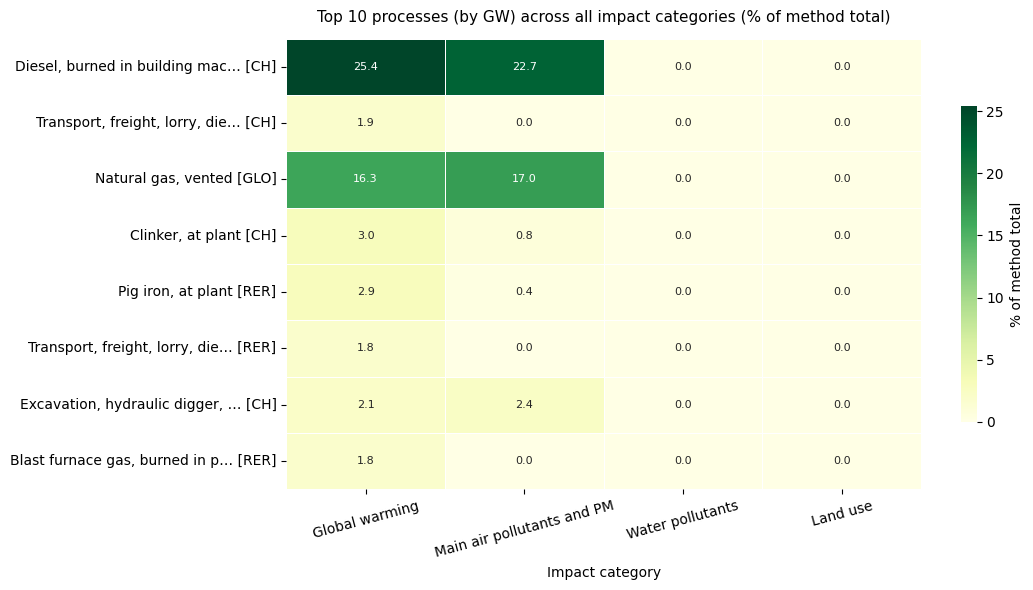

In [12]:
fig, ax = plt.subplots(figsize=(11, 6))

sns.heatmap(
    df_proc_methods,
    annot=True,
    fmt='.1f',
    cmap='YlGn',
    linewidths=0.4,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': '% of method total', 'shrink': 0.7},
    annot_kws={'size': 8},
)
ax.set_title(
    "Top 10 processes (by GW) across all impact categories (% of method total)",
    fontsize=11, pad=12,
)
ax.set_xlabel("Impact category", fontsize=10)
ax.set_ylabel("")
ax.tick_params(axis='x', labelrotation=15)
ax.tick_params(axis='y', labelrotation=0)
plt.tight_layout()
plt.show()

---

## 6 — Recursive Supply-Chain Traversal

`bw2analyzer` provides two functions for walking the supply chain tree:

| Function | Shows |
|---|---|
| `ba.print_recursive_supply_chain(activity)` | Physical amounts consumed at each level |
| `ba.print_recursive_calculation(activity, method)` | LCIA contribution fraction at each level |

Both functions accept:
- `max_level` — how many layers deep to traverse (default 2)
- `cutoff` — skip branches contributing less than this fraction of the total (default 0.01 for recursive_calculation)
- `amount` — starting demand amount

These functions work best with **`processwithreferenceproduct`** nodes such as those in BAFU-2025-v2, where each node is simultaneously a process and its reference product. Below we trace the excavation process — a significant contributor to the construction phase — down two levels into its background supply chain.

In [13]:
print(f"Excavation: {excavation['name']} ({excavation['location']})")
print(f"Unit: {excavation['unit']}")
print(f"Number of technosphere inputs: {len(list(excavation.technosphere()))}")
print()
print("=== Supply-chain tree (physical quantities) ===")
ba.print_recursive_supply_chain(excavation, amount=25, max_level=2)

Excavation: Excavation, hydraulic digger, average (CH)
Unit: cubic meter
Number of technosphere inputs: 4

=== Supply-chain tree (physical quantities) ===
25: 'Excavation, hydraulic digger, average' (cubic meter, CH, ['construction processes', 'civil engineering'])
  0.0452: 'Disposal, used mineral oil, 10% water, to hazardous waste incineration' (kilogram, CH, ['incineration', 'hazardous wast
    2.29e-07: 'Chemicals organic, at plant' (kilogram, GLO, ['chemicals', 'organic'])
    0.000207: 'Cement, unspecified, at plant' (kilogram, CH, ['construction', 'binders'])
    8.86e-07: 'Hydrochloric acid, 30% in H2O, at plant' (kilogram, RER, ['chemicals', 'acids (inorganic)'])
    5.65e-11: 'Hazardous waste incineration plant' (unit, CH, ['waste', 'infrastructure'])
    0.000516: 'Process-specific burdens, residual material landfill' (kilogram, CH, ['landfill', 'residual material landfill'])
    0.0452: 'Process-specific burdens, hazardous waste incineration plant' (kilogram, CH, ['incinera

In [14]:
print("=== Supply-chain tree (Global Warming contributions) ===")
print("Format: fraction_of_score | absolute_score | amount | activity")
print()
ba.print_recursive_calculation(
    excavation,
    ("Ecological Scarcity 2021", "Global warming"),
    amount=25,
    max_level=2,
    cutoff=0.005,
)

=== Supply-chain tree (Global Warming contributions) ===
Format: fraction_of_score | absolute_score | amount | activity

Fraction of score | Absolute score | Amount | Activity
0001 |  9112 |    25 | 'Excavation, hydraulic digger, average' (cubic meter, CH, ['construction processes', 'civil engineering'])


/Users/cmutel/virtualenvs/trondheim/lib/python3.14/site-packages/scikits/umfpack/umfpack.py:737: UmfpackWarning: (almost) singular matrix! (estimated cond. number: 1.56e+12)
  warnings.warn(msg, UmfpackWarning)


  0.045 | 410.3 | 2.5e-05 | 'Hydraulic digger' (unit, RER, ['construction processes', 'building equipment\\infrastructure'])
    0.0243 | 221.3 | 0.2625 | 'Reinforcing steel, at plant' (kilogram, RER, ['metals', 'extraction'])
    0.0172 | 156.9 | 0.1125 | 'Steel, low-alloyed, at plant' (kilogram, RER, ['metals', 'ferro'])
  0.119 |  1085 | 2.368 | 'Diesel, at regional storage' (kilogram, CH, ['oil', 'distribution'])
    0.0414 | 377.3 | 0.7543 | 'Diesel, at refinery' (kilogram, CH, ['oil', 'fuels'])
    0.0725 | 660.6 | 1.553 | 'Diesel, at refinery' (kilogram, RER, ['oil', 'fuels'])


For the foreground system, where the top-level processes (construction, maintenance, etc.) connect directly to BAFU background processes, we can also traverse from a foreground process node. The traversal follows `.technosphere()` edges, so it picks up all BAFU inputs at the next level:

In [15]:
print("=== Garden construction — supply chain (max 1 level) ===")
ba.print_recursive_supply_chain(constr_prod, amount=1, max_level=1)
print()
print("=== Garden construction — Global Warming contributions ===")
ba.print_recursive_calculation(
    constr_prod,
    ("Ecological Scarcity 2021", "Global warming"),
    amount=1,
    max_level=1,
    cutoff=0.01,
)

=== Garden construction — supply chain (max 1 level) ===
1: 'Garden' (unit, CH, None)

=== Garden construction — Global Warming contributions ===
Fraction of score | Absolute score | Amount | Activity
0001 | 3.146e+05 |     1 | 'Garden' (unit, CH, None)


---

## 7 — Where Is the Impact Concentrated?

A useful diagnostic question: is the LCIA score spread evenly across thousands of processes, or dominated by a handful? The answer affects how much effort it's worth investing in detailed data collection for specific processes.

`bw2analyzer.econ` provides several concentration metrics borrowed from economics:

| Metric | Range | Interpretation |
|---|---|---|
| **Gini coefficient** | 0 – 1 | 0 = perfectly equal; 1 = one process has all the impact |
| **Herfindahl–Hirschman index** | 0 – 1 | Sum of squared market shares; > 0.25 = highly concentrated |
| **Concentration ratio (CR1)** | 0 – 1 | Share of impact held by the single largest contributor |
| **Theil index** | 0 – ∞ | Entropy-based inequality measure |

These are applied to the non-zero positive values of `lca.characterized_inventory.data`.

In [16]:
# Restore full garden LCA, Global Warming
lca.switch_method(METHODS[0])
lca.redo_lci({garden_prod.id: 1})
lca.redo_lcia()

# Positive contributions only (some may be negative, e.g. credits)
impact_values = lca.characterized_inventory.data
impact_pos = impact_values[impact_values > 0]

print(f"Total non-zero entries in characterized inventory: {len(impact_values):,}")
print(f"Positive entries:                                  {len(impact_pos):,}")
print(f"Total score (sum of positive):                     {impact_pos.sum():,.0f} UBP")
print()
print(f"Gini coefficient:    {gini_coefficient(impact_pos):.3f}  (0=equal, 1=concentrated)")
print(f"Herfindahl index:    {herfindahl_index(impact_pos):.5f}")
print(f"Concentration CR1:   {concentration_ratio(impact_pos):.3f}  (share of largest entry)")
print(f"Theil index:         {theil_index(impact_pos):.3f}")

Total non-zero entries in characterized inventory: 1,204
Positive entries:                                  1,203
Total score (sum of positive):                     377,568 UBP

Gini coefficient:    0.983  (0=equal, 1=concentrated)
Herfindahl index:    0.12283
Concentration CR1:   0.613  (share of largest entry)
Theil index:         4.137


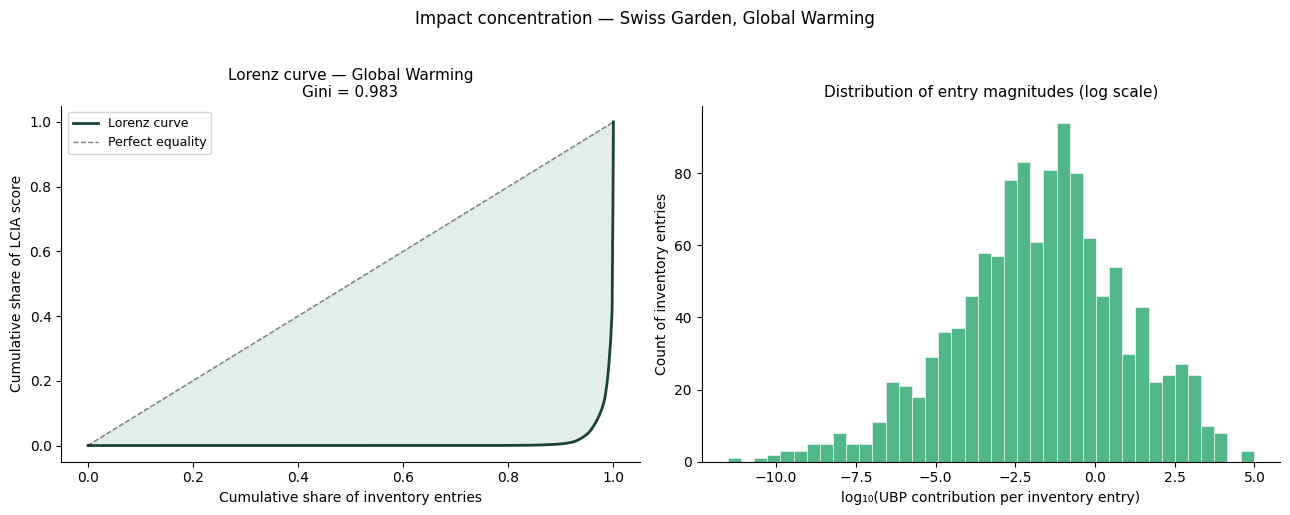

In [17]:
# Visualise the concentration with a Lorenz curve
sorted_vals = np.sort(impact_pos)
cum_share = np.cumsum(sorted_vals) / sorted_vals.sum()
pop_share = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: Lorenz curve ────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(pop_share, cum_share, color='#1b4332', linewidth=2, label='Lorenz curve')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Perfect equality')
ax.fill_between(pop_share, cum_share, pop_share, alpha=0.15, color='#40916c')
ax.set_xlabel("Cumulative share of inventory entries", fontsize=10)
ax.set_ylabel("Cumulative share of LCIA score", fontsize=10)
ax.set_title(
    f"Lorenz curve — Global Warming\n"
    f"Gini = {gini_coefficient(impact_pos):.3f}",
    fontsize=11,
)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=9)

# ── Right: log-scale distribution of entry magnitudes ─────────────────────────
ax = axes[1]
ax.hist(
    np.log10(sorted_vals[sorted_vals > 0]),
    bins=40, color='#52b788', edgecolor='white', linewidth=0.4,
)
ax.set_xlabel("log₁₀(UBP contribution per inventory entry)", fontsize=10)
ax.set_ylabel("Count of inventory entries", fontsize=10)
ax.set_title(
    "Distribution of entry magnitudes (log scale)",
    fontsize=11,
)
ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(
    "Impact concentration — Swiss Garden, Global Warming",
    fontsize=12, y=1.02,
)
plt.tight_layout()
plt.show()

---

## 8 — Sensitivity: How Much Does the Top Process Matter?

A final practical question: if we halve the amount of the single most impactful input, how much does the total score change? This is a simple but powerful sensitivity test — it tells you which data points are worth collecting more carefully.

We do this by modifying the technosphere matrix directly and re-solving the LCA. `bw2calc` provides `lca.rebuild_technosphere_matrix()` and `lca.rebuild_biosphere_matrix()` after you modify the underlying data, but the simplest approach for a one-off test is to just rebuild the full LCA with the modified exchange amount.

In [18]:
# Restore baseline Global Warming score
lca.switch_method(METHODS[0])
lca.redo_lci({garden_prod.id: 1})
lca.redo_lcia()
baseline_score = lca.score

# Identify the top process again
top_procs_gw = ca.annotated_top_processes(lca, limit=1)
top_score, top_supply, top_act = top_procs_gw[0]

print(f"Baseline score:       {baseline_score:,.0f} UBP")
print(f"Top process:          {top_act['name']} [{top_act.get('location','GLO')}]")
print(f"  Database:           {top_act['database']}")
print(f"  Contribution:       {top_score:,.0f} UBP ({100*top_score/baseline_score:.1f}% of total)")
print(f"  Supply amount:      {top_supply:.4g} {top_act.get('unit', 'unit')}")
print()
print(f"If this process ran at half the amount, the score would decrease by approximately:")
print(f"  {top_score / 2:,.0f} UBP  →  new total ≈ {baseline_score - top_score/2:,.0f} UBP")
print(f"  ({100 * (top_score/2) / baseline_score:.1f}% reduction)")

Baseline score:       377,568 UBP
Top process:          Diesel, burned in building machine, average [CH]
  Database:           BAFU-2025-v2
  Contribution:       95,934 UBP (25.4% of total)
  Supply amount:      1284 megajoule

If this process ran at half the amount, the score would decrease by approximately:
  47,967 UBP  →  new total ≈ 329,601 UBP
  (12.7% reduction)


---

## 9 — Comparing Two Methods Directly

Sometimes you need to report results for two methods side-by-side at the process level — for instance, to show a reviewer that your conclusions are robust. The code below computes the top-process ranking for Global Warming and for Land Use simultaneously, and plots them together to highlight where the rankings agree and diverge.

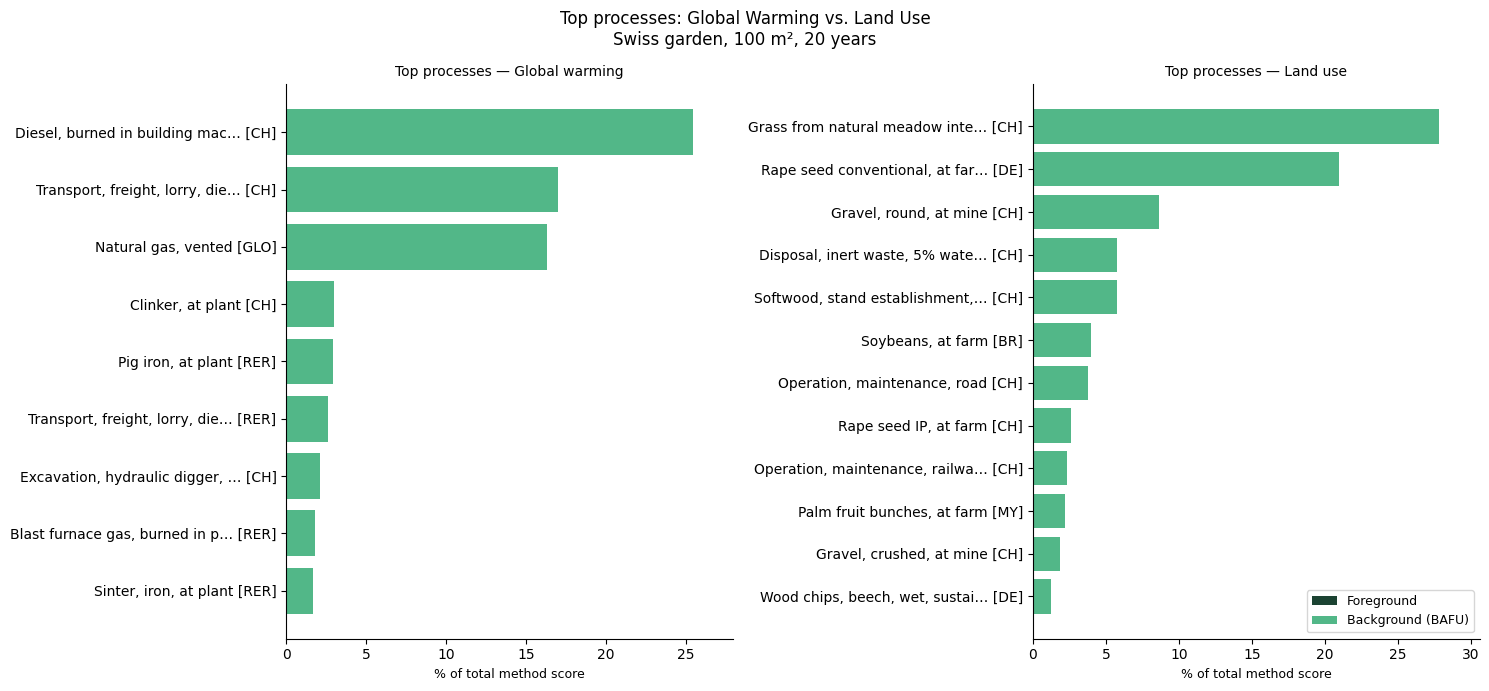

In [19]:
def top_process_df(lca_obj, method, limit=12):
    """Return a DataFrame of top processes for a given method."""
    lca_obj.switch_method(method)
    lca_obj.redo_lci({garden_prod.id: 1})
    lca_obj.redo_lcia()
    rows = []
    for score, supply, act in ca.annotated_top_processes(lca_obj, limit=limit):
        rows.append({
            'label': (
                f"{act['name'][:30]}… [{act.get('location','GLO')}]"
                if len(act['name']) > 30
                else f"{act['name']} [{act.get('location','GLO')}]"
            ),
            'score': score,
            'pct': 100 * abs(score) / abs(lca_obj.score),
            'database': act['database'],
        })
    return pd.DataFrame(rows)

df_gw = top_process_df(lca, METHODS[0], limit=12)   # Global warming
df_lu = top_process_df(lca, METHODS[3], limit=12)   # Land use

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

for ax, df, method in zip(axes, [df_gw, df_lu], [METHODS[0], METHODS[3]]):
    colors = [
        '#1b4332' if db == 'Swiss garden foreground' else '#52b788'
        for db in df['database']
    ]
    ax.barh(df['label'], df['pct'], color=colors)
    ax.set_xlabel("% of total method score", fontsize=9)
    ax.set_title(f"Top processes — {method[1]}", fontsize=10)
    ax.invert_yaxis()
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlim(0, max(df['pct'].max(), 5) * 1.1)

legend_elements = [
    Patch(facecolor='#1b4332', label='Foreground'),
    Patch(facecolor='#52b788', label='Background (BAFU)'),
]
axes[1].legend(handles=legend_elements, loc='lower right', fontsize=9)

fig.suptitle(
    "Top processes: Global Warming vs. Land Use\nSwiss garden, 100 m², 20 years",
    fontsize=12,
)
plt.tight_layout()
plt.show()

---

## 10 — Supply-Chain Traversal with `bw_graph_tools`

`bw2analyzer`'s recursive functions print a text tree but don't return structured data. The [`bw_graph_tools`](https://github.com/brightway-lca/bw_graph_tools) package provides a proper **priority-first** traversal that returns `Node`, `Edge`, and `Flow` dataclasses you can query, filter, and visualise.

`NewNodeEachVisitGraphTraversal` always expands the node with the highest *remaining cumulative impact* first, so the most important supply-chain paths are visited before low-impact branches. The traversal halts when the remaining uncaptured impact falls below `cutoff × total_score` or `max_calc` nodes have been expanded.

Key fields of a traversal `Node`:

| Field | Meaning |
|---|---|
| `unique_id` | ID within this traversal run (virtual root = −1) |
| `activity_datapackage_id` | Brightway `node.id` — look up with `bd.get_node(id=...)` |
| `cumulative_score` | Impact from this process *and* its entire upstream supply chain |
| `direct_emissions_score` | Impact from direct biosphere flows only |
| `supply_amount` | How much of this process runs per functional unit |
| `depth` | Number of edges from the functional unit |
| `terminal` | `True` if traversal stopped here (cutoff reached or max_calc hit) |

In [20]:
# Restore full-garden Global Warming LCA
lca.switch_method(METHODS[0])
lca.redo_lci({garden_prod.id: 1})
lca.redo_lcia()

settings = GraphTraversalSettings(cutoff=0.005, max_calc=2000)
gt = NewNodeEachVisitGraphTraversal(lca, settings)
gt.traverse()

print(f"LCA score:             {lca.score:,.0f} UBP")
print(f"Nodes visited:         {len(gt.nodes)}")
print(f"Edges (supply links):  {len(gt.edges)}")
print(f"Biosphere flows:       {len(gt.flows)}")

LCA score:             377,568 UBP
Nodes visited:         102
Edges (supply links):  101
Biosphere flows:       32


/Users/cmutel/virtualenvs/trondheim/lib/python3.14/site-packages/bw_graph_tools/graph_traversal/new_node_each_visit.py:349: UserWarning: Graph traversal covered only 57.3% of the total LCA score. Consider lowering the `cutoff` (currently 0.005) to improve coverage.
  warnings.warn(


In [21]:
VIRTUAL_ROOT_ID = -1

rows = []
for node in gt.nodes.values():
    if node.unique_id == VIRTUAL_ROOT_ID:
        continue
    act = bd.get_node(id=node.activity_datapackage_id)
    rows.append({
        'Name': act['name'],
        'Location': act.get('location', 'GLO'),
        'Database': act['database'],
        'Cumulative (UBP)': node.cumulative_score,
        'Direct (UBP)': node.direct_emissions_score,
        'Upstream (UBP)': node.cumulative_score - node.direct_emissions_score,
        'Supply': node.supply_amount,
        'Depth': node.depth,
        'Terminal': node.terminal,
        'unique_id': node.unique_id,
    })

df_trav = pd.DataFrame(rows).sort_values('Cumulative (UBP)', ascending=False)
n_terminal = df_trav['Terminal'].sum()
print(f"Traversal captured {len(df_trav)} nodes "
      f"({n_terminal} terminal, {len(df_trav) - n_terminal} fully expanded)")
df_trav[['Name', 'Location', 'Database', 'Cumulative (UBP)', 'Direct (UBP)', 'Depth', 'Terminal']].head(15)

Traversal captured 101 nodes (44 terminal, 57 fully expanded)


,Name,Location,Database,Cumulative (UBP),Direct (UBP),Depth,Terminal
0,Garden system,CH,Swiss garden foreground,3.776e+05,0,1,False
1,Garden construction,CH,Swiss garden foreground,3.146e+05,0,2,False
6,"Natural stone plate, cut, market mix, at regional s...",CH,BAFU-2025-v2,2.05e+05,0,3,False
13,"Natural stone plate, cut, at regional storage",CH,BAFU-2025-v2,1.444e+05,0,4,False
14,"Diesel, burned in building machine, average",CH,BAFU-2025-v2,9.576e+04,8.003e+04,5,False
10,"Transport, freight, lorry, diesel, 18t gross weight...",CH,BAFU-2025-v2,7.942e+04,6.242e+04,3,False
11,"Transport, freight, lorry, fleet average",RER,BAFU-2025-v2,5.629e+04,0,4,False
2,Annual garden maintenance,CH,Swiss garden foreground,4.695e+04,0,2,False
15,"Transport, freight, lorry, 16t-32t gross weight, fl...",CH,BAFU-2025-v2,4.177e+04,0,5,False
23,"Transport, freight, lorry, 32t-40t gross weight, fl...",RER,BAFU-2025-v2,3.036e+04,0,5,False


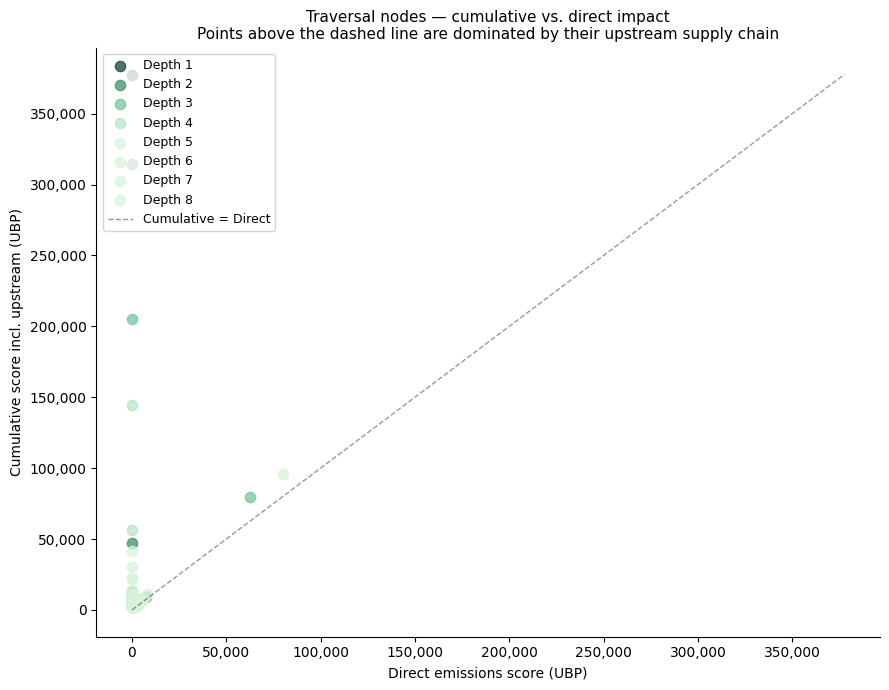

In [22]:
fig, ax = plt.subplots(figsize=(9, 7))

palette = {1: '#1b4332', 2: '#40916c', 3: '#74c69d', 4: '#b7e4c7'}

for depth in sorted(df_trav['Depth'].unique()):
    mask = df_trav['Depth'] == depth
    color = palette.get(int(depth), '#d8f3dc')
    ax.scatter(
        df_trav.loc[mask, 'Direct (UBP)'],
        df_trav.loc[mask, 'Cumulative (UBP)'],
        color=color, alpha=0.75, s=55,
        label=f"Depth {depth}",
    )

# 1:1 line: nodes on it have no upstream impact (cumulative = direct)
upper = max(df_trav['Cumulative (UBP)'].max(), df_trav['Direct (UBP)'].max())
lower = min(0, df_trav['Direct (UBP)'].min())
ax.plot([lower, upper], [lower, upper],
        'k--', linewidth=1, alpha=0.4, label='Cumulative = Direct')

ax.set_xlabel("Direct emissions score (UBP)", fontsize=10)
ax.set_ylabel("Cumulative score incl. upstream (UBP)", fontsize=10)
ax.set_title(
    "Traversal nodes — cumulative vs. direct impact\n"
    "Points above the dashed line are dominated by their upstream supply chain",
    fontsize=11,
)
ax.legend(fontsize=9, loc='upper left')
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

### Supply-chain graph

The scatter plot above shows each node in isolation. A graph layout makes the *relationships* visible: which foreground processes call which background processes, and how the high-impact nodes cluster by depth.

`plot_traversal_graph` filters to the top-N nodes by cumulative score, builds a `networkx.DiGraph` from the traversal edges, then positions nodes on a depth-based grid — functional unit at the left, upstream processes extending to the right. Arrows run **consumer → producer**, reading left-to-right as *"A needs B needs C"*. Node size scales with cumulative score, so the biggest circles are the biggest drivers.

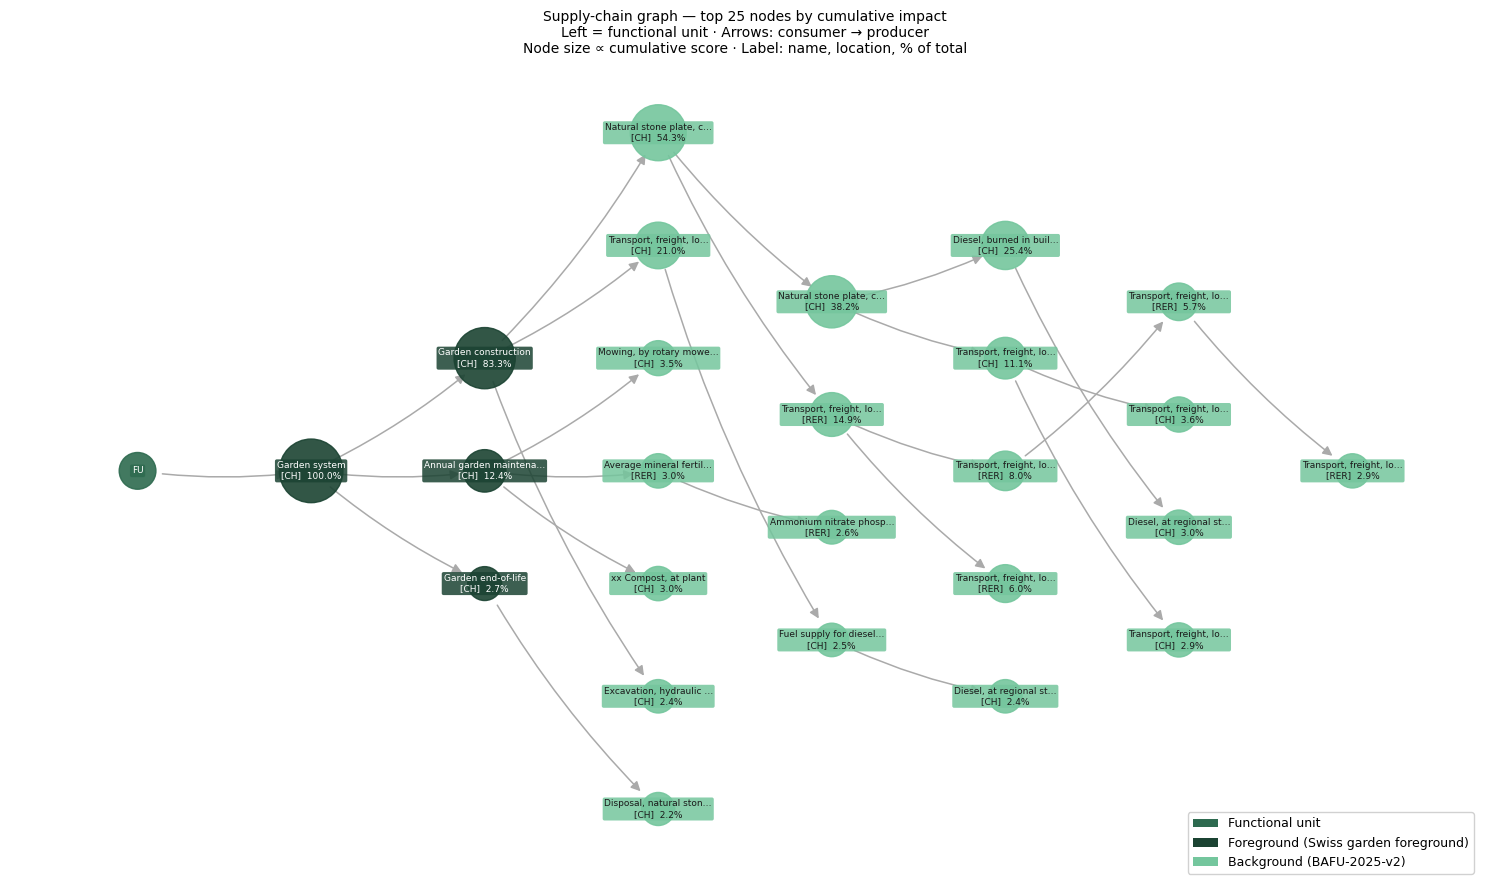

In [23]:
import networkx as nx

def plot_traversal_graph(
    gt,
    lca,
    top_n=25,
    foreground_db="Swiss garden foreground",
    figsize=(15, 9),
):
    """
    Draw the top_n traversal nodes as a directed supply-chain graph.

    Layout: functional unit at left (depth 0), upstream processes extend right.
    Arrows run consumer → producer, reading left-to-right as "A needs B needs C…".
    Node size ∝ cumulative score; labels show name, location, and % of LCA total.
    """
    VIRTUAL_ROOT_ID = -1

    # ── 1. Select top-N nodes ─────────────────────────────────────────────────
    candidates = [n for uid, n in gt.nodes.items() if uid != VIRTUAL_ROOT_ID]
    top_nodes = sorted(candidates, key=lambda n: n.cumulative_score, reverse=True)[:top_n]
    top_uids = {n.unique_id for n in top_nodes} | {VIRTUAL_ROOT_ID}

    # ── 2. Fetch Brightway metadata ───────────────────────────────────────────
    meta = {
        VIRTUAL_ROOT_ID: {
            'name': 'Functional unit', 'location': '',
            'database': '_root', 'cumulative': lca.score, 'depth': 0,
        }
    }
    for node in top_nodes:
        act = bd.get_node(id=node.activity_datapackage_id)
        meta[node.unique_id] = {
            'name': act['name'],
            'location': act.get('location', 'GLO'),
            'database': act['database'],
            'cumulative': node.cumulative_score,
            'depth': node.depth,
        }

    # ── 3. Build directed graph: consumer → producer ("A needs B") ─────────────
    G = nx.DiGraph()
    for uid in top_uids:
        G.add_node(uid, **meta[uid])
    for edge in gt.edges:
        prod, cons = edge.producer_unique_id, edge.consumer_unique_id
        if prod in top_uids and cons in top_uids:
            G.add_edge(cons, prod)

    # ── 4. Depth-based hierarchical layout ───────────────────────────────────
    by_depth: dict[int, list] = {}
    for uid in G.nodes:
        by_depth.setdefault(meta[uid]['depth'], []).append(uid)

    pos = {}
    for depth, uids_at_d in by_depth.items():
        uids_at_d.sort(key=lambda u: meta[u]['cumulative'], reverse=True)
        n = len(uids_at_d)
        for i, uid in enumerate(uids_at_d):
            pos[uid] = (depth * 2.8, -(i - (n - 1) / 2) * 2.0)

    # ── 5. Visual properties ──────────────────────────────────────────────────
    max_cum = max(meta[u]['cumulative'] for u in G.nodes)

    node_colors, node_sizes = [], []
    for uid in G.nodes:
        db   = meta[uid]['database']
        frac = max(meta[uid]['cumulative'], 0) / max_cum
        size = 300 + 1800 * frac ** 0.5
        if db == '_root':
            node_colors.append('#2d6a4f');  node_sizes.append(700)
        elif db == foreground_db:
            node_colors.append('#1b4332');  node_sizes.append(size)
        else:
            node_colors.append('#74c69d');  node_sizes.append(size)

    labels = {}
    for uid in G.nodes:
        m = meta[uid]
        if m['database'] == '_root':
            labels[uid] = 'FU'
        else:
            short = m['name'][:22] + '…' if len(m['name']) > 22 else m['name']
            pct   = 100 * m['cumulative'] / lca.score
            labels[uid] = f"{short}\n[{m['location']}]  {pct:.1f}%"

    # ── 6. Draw ───────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize)

    nx.draw_networkx_edges(
        G, pos, ax=ax,
        arrows=True, arrowsize=14,
        edge_color='#aaaaaa', width=1.1,
        connectionstyle='arc3,rad=0.07',
        min_source_margin=18, min_target_margin=18,
    )
    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_size=node_sizes, node_color=node_colors, alpha=0.9,
    )

    # Each group gets a bbox whose facecolor matches the node, so text never
    # bleeds onto the white figure background.
    label_groups = [
        ([u for u in G.nodes if meta[u]['database'] == '_root'],       '#2d6a4f', 'white'),
        ([u for u in G.nodes if meta[u]['database'] == foreground_db], '#1b4332', 'white'),
        ([u for u in G.nodes if meta[u]['database'] not in ('_root', foreground_db)],
         '#74c69d', '#1a1a1a'),
    ]
    for uids, face, font in label_groups:
        if uids:
            nx.draw_networkx_labels(
                G, pos, {u: labels[u] for u in uids}, ax=ax,
                font_size=6.5, font_color=font,
                bbox=dict(boxstyle='round,pad=0.2', facecolor=face, edgecolor='none', alpha=0.85),
            )

    ax.legend(
        handles=[
            Patch(facecolor='#2d6a4f', label='Functional unit'),
            Patch(facecolor='#1b4332', label=f'Foreground ({foreground_db})'),
            Patch(facecolor='#74c69d', label='Background (BAFU-2025-v2)'),
        ],
        loc='lower right', fontsize=9, framealpha=0.9,
    )
    ax.set_title(
        f"Supply-chain graph — top {top_n} nodes by cumulative impact\n"
        "Left = functional unit · Arrows: consumer → producer\n"
        "Node size ∝ cumulative score · Label: name, location, % of total",
        fontsize=10,
    )
    ax.axis('off')
    plt.tight_layout()
    plt.show()


plot_traversal_graph(gt, lca, top_n=25)

In [24]:
# Highest-impact background node (excluding foreground)
top_bg = df_trav[df_trav['Database'] == 'BAFU-2025-v2'].iloc[0]
top_bg_uid = int(top_bg['unique_id'])
top_bg_node = gt.nodes[top_bg_uid]

print("Top background node:")
print(f"  {top_bg['Name']} [{top_bg['Location']}]")
print(f"  Cumulative: {top_bg_node.cumulative_score:,.0f} UBP"
      f"  ({100 * top_bg_node.cumulative_score / lca.score:.1f}% of total)")
print(f"  Direct:     {top_bg_node.direct_emissions_score:,.0f} UBP")
print(f"  Upstream:   {top_bg_node.cumulative_score - top_bg_node.direct_emissions_score:,.0f} UBP")
print()

# Direct biosphere flows for this node captured by the traversal
node_flows = sorted(
    [f for f in gt.flows if f.activity_unique_id == top_bg_uid],
    key=lambda f: abs(f.score), reverse=True,
)
if node_flows:
    flow_rows = []
    for f in node_flows[:10]:
        bio = bd.get_node(id=f.flow_datapackage_id)
        denom = top_bg_node.direct_emissions_score or float('nan')
        flow_rows.append({
            'Elementary flow': bio['name'],
            'Categories': ' > '.join(bio.get('categories', [])),
            'Score (UBP)': f.score,
            '% of node direct': 100 * f.score / denom,
        })
    print("Top 10 biosphere flows for this node:")
    display(pd.DataFrame(flow_rows))
else:
    print("No biosphere flows captured for this node (terminal node or zero direct emissions).")

Top background node:
  Natural stone plate, cut, market mix, at regional storage [CH]
  Cumulative: 205,021 UBP  (54.3% of total)
  Direct:     0 UBP
  Upstream:   205,021 UBP

No biosphere flows captured for this node (terminal node or zero direct emissions).


### Tracing the supply-chain path

Each traversal `Edge` stores `producer_unique_id` → `consumer_unique_id` (the upstream process → the downstream process that consumes it). Inverting this map lets us walk any node back to the virtual root (unique_id = −1), revealing the exact supply-chain path that brought this process into the LCA.

In [25]:
def trace_to_root(target_uid, nodes, edges, root_id=-1):
    """Return list of unique_ids on the path from root to target_uid."""
    parent = {e.producer_unique_id: e.consumer_unique_id for e in edges}
    path = []
    uid = target_uid
    while uid != root_id:
        path.append(uid)
        uid = parent.get(uid, root_id)
    path.append(root_id)
    path.reverse()
    return path


path_uids = trace_to_root(top_bg_uid, gt.nodes, gt.edges)

print(f"Supply-chain path: functional unit → {top_bg['Name']}\n")
for i, uid in enumerate(path_uids):
    indent = "  " * i
    if uid == VIRTUAL_ROOT_ID:
        print(f"{indent}[functional unit — Swiss garden, 1 unit]")
    else:
        node = gt.nodes[uid]
        act = bd.get_node(id=node.activity_datapackage_id)
        pct = 100 * node.cumulative_score / lca.score
        print(
            f"{indent}→ {act['name']} [{act.get('location', 'GLO')}]"
            f"  |  cumul. {pct:.1f}%  |  depth {node.depth}"
        )

Supply-chain path: functional unit → Natural stone plate, cut, market mix, at regional storage

[functional unit — Swiss garden, 1 unit]
  → Garden system [CH]  |  cumul. 100.0%  |  depth 1
    → Garden construction [CH]  |  cumul. 83.3%  |  depth 2
      → Natural stone plate, cut, market mix, at regional storage [CH]  |  cumul. 54.3%  |  depth 3


---

## Summary

| Tool | What it answers | Key function / class |
|---|---|---|
| Top-process contribution | Which activities drive the score? | `ba.ContributionAnalysis().annotated_top_processes(lca)` |
| Top-flow contribution | Which substances matter most? | `ba.ContributionAnalysis().annotated_top_emissions(lca)` |
| Phase breakdown | Which life-cycle stage dominates? | `lca.redo_lci(phase_demand)` |
| Multi-method heatmap | Does the ranking shift between categories? | `sns.heatmap(results_pct.T, ...)` |
| Recursive traversal (text) | What drives a specific process? | `ba.print_recursive_calculation(act, method)` |
| Concentration metrics | Is the score spread or focused? | `ba.econ.gini_coefficient(impact_values)` |
| Sensitivity test | Which input is worth refining? | Scale by fraction, check Δscore |
| Graph traversal | Structured Node/Edge/Flow data for the whole supply chain | `NewNodeEachVisitGraphTraversal(lca, settings).traverse()` |
| Supply-chain graph | Which processes are connected, and how big is each driver? | `plot_traversal_graph(gt, lca, top_n=25)` |
| Path trace | Which supply-chain path brings a process into the LCA? | Edge-based `trace_to_root(uid, nodes, edges)` |

**Key implementation notes:**
- Reuse `lca.redo_lci()` / `lca.switch_method()` to avoid recomputing the LU decomposition of **A** for every scenario.
- `lca.characterized_inventory` (flows × processes) is the richest data structure — most interpretation tools are summaries of it.
- Recursive traversal functions (`ba.print_recursive_calculation`, `ba.print_recursive_supply_chain`) work best with `processwithreferenceproduct` nodes (BAFU, ecoinvent). For foreground systems with separate process and product nodes, traverse from the *process* node, not the product node.
- `NewNodeEachVisitGraphTraversal` handles mixed foreground/background systems. Use `node.activity_datapackage_id` (not `node.unique_id`) to look up Brightway metadata with `bd.get_node(id=...)`. The virtual root node has `unique_id = -1`.
- `plot_traversal_graph` uses a depth-based grid layout — nodes at the same supply-chain depth are stacked vertically, sorted by cumulative score, making it easy to see which depth level contains the biggest drivers.